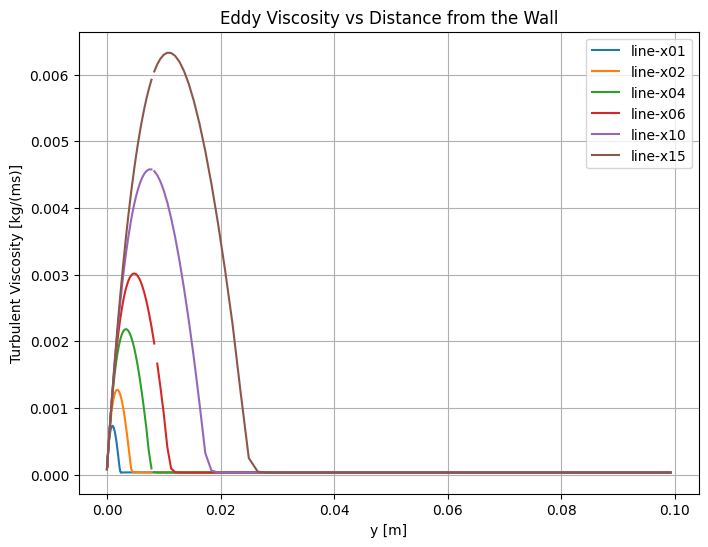

         Position  line-x01  line-x02  line-x04  line-x06  line-x10  line-x15
0    5.002330e-07  0.000084  0.000084  0.000084  0.000084  0.000084  0.000084
1    1.502560e-06  0.000086  0.000085  0.000085  0.000085  0.000085  0.000085
2    2.510480e-06  0.000087  0.000087  0.000087  0.000087  0.000087  0.000087
3    3.527740e-06  0.000088  0.000088  0.000088  0.000088  0.000088  0.000088
4    4.558140e-06  0.000090  0.000090  0.000089  0.000089  0.000089  0.000089
..            ...       ...       ...       ...       ...       ...       ...
154  7.957790e-02  0.000035  0.000035  0.000033  0.000033  0.000031  0.000030
155  8.458320e-02  0.000035  0.000035  0.000033  0.000033  0.000031  0.000030
156  8.990340e-02  0.000035  0.000035  0.000033  0.000033  0.000031  0.000030
157  9.555820e-02  0.000035  0.000035  0.000033  0.000033  0.000031  0.000030
158  9.923590e-02  0.000035  0.000035  0.000033  0.000033  0.000031  0.000030

[159 rows x 7 columns]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def read_xy_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and merge
    merged_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on=label_x, how="outer")  # Merge on the first column

    
    return merged_df, label_x


# Example usage
file_path = r"C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise7\ke_coarse_eddy_viscosity"  # Update with your actual file path
df, x_label = read_xy_file(file_path)
def plot_xy_data(df, x_label):
    plt.figure(figsize=(8, 6))

    # Plot each data block (column) against Z-Coordinate
    for col in df.columns[1:]:  # Skip first column (Z-Coordinate)
        plt.plot(df[x_label], df[col], label=col)

    plt.xlabel("y [m]")
    plt.ylabel("Turbulent Viscosity [kg/(ms)]")
    plt.title("Eddy Viscosity vs Distance from the Wall")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
df, x_label = read_xy_file(file_path)

plot_xy_data(df, x_label)

print(df)


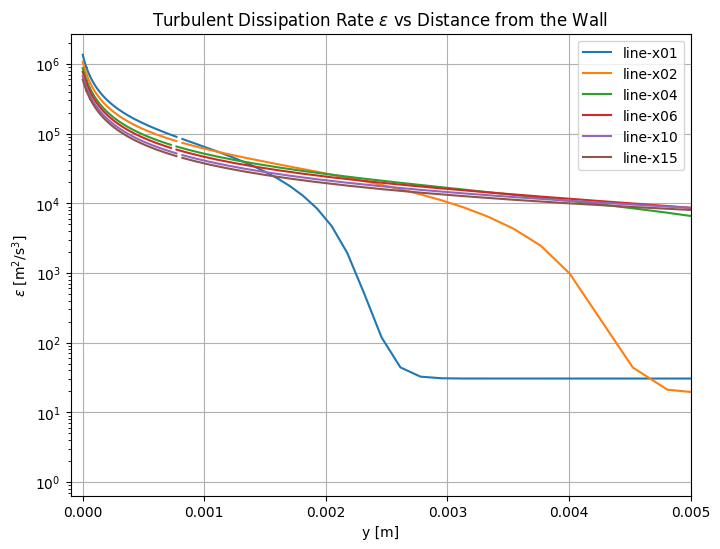

         Position      line-x01      line-x02      line-x04      line-x06  \
0    5.002330e-07  1.358330e+06  1.078370e+06  872094.00000  772637.00000   
1    1.502560e-06  1.335340e+06  1.060900e+06  858595.00000  761001.00000   
2    2.510480e-06  1.313060e+06  1.043920e+06  845449.00000  749657.00000   
3    3.527740e-06  1.291300e+06  1.027320e+06  832569.00000  738533.00000   
4    4.558140e-06  1.269970e+06  1.011010e+06  819903.00000  727586.00000   
..            ...           ...           ...           ...           ...   
154  7.957790e-02  3.060290e+01  1.854100e+01       9.08020       5.34163   
155  8.458320e-02  3.060450e+01  1.854180e+01       9.08045       5.34174   
156  8.990340e-02  3.060610e+01  1.854260e+01       9.08070       5.34184   
157  9.555820e-02  3.060780e+01  1.854340e+01       9.08096       5.34195   
158  9.923590e-02  3.060950e+01  1.854420e+01       9.08124       5.34207   

         line-x10      line-x15  
0    665757.00000  595071.00000  
1    65

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def read_xy_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and merge
    merged_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on=label_x, how="outer")  # Merge on the first column

    
    return merged_df, label_x


# Example usage
file_path = r"C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise7\ke_coarse_epsilon"  # Update with your actual file path
df, x_label = read_xy_file(file_path)
def plot_xy_data(df, x_label):
    plt.figure(figsize=(8, 6))

    # Plot each data block (column) against Z-Coordinate
    for col in df.columns[1:]:  # Skip first column (Z-Coordinate)
        plt.plot(df[x_label], df[col], label=col)

    plt.xlim(-0.0001,0.005)
    plt.yscale('log')
    plt.xlabel("y [m]")
    plt.ylabel(r"$\varepsilon$ [m$^2$/s$^3$]")
    plt.title(r"Turbulent Dissipation Rate $\varepsilon$ vs Distance from the Wall")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
df, x_label = read_xy_file(file_path)

plot_xy_data(df, x_label)

print(df)


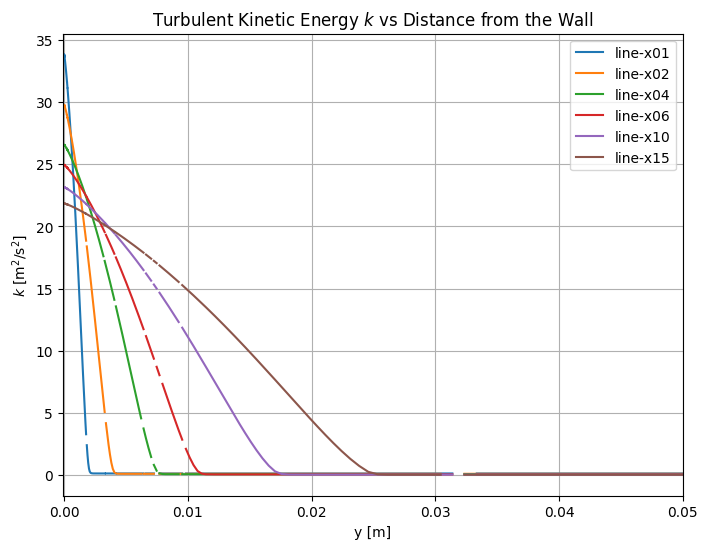

         Position   line-x01   line-x02   line-x04   line-x06   line-x10  \
0    2.500000e-07  33.809000  29.751000  26.549200  24.937400  23.140700   
1    7.502330e-07  33.808800  29.750900  26.549200  24.937400  23.140700   
2    1.251160e-06  33.808800  29.751000  26.549300  24.937500  23.140700   
3    1.753260e-06  33.808700  29.751000  26.549300  24.937500  23.140800   
4    2.256980e-06  33.808500  29.751000  26.549400  24.937600  23.140900   
..            ...        ...        ...        ...        ...        ...   
320  8.851190e-02   0.127851   0.100374   0.070027   0.053513   0.036239   
321  9.125310e-02   0.127853   0.100375   0.070027   0.053513   0.036239   
322  9.407920e-02   0.127854   0.100376   0.070027   0.053513   0.036239   
323  9.699280e-02   0.127856   0.100376   0.070028   0.053513   0.036239   
324  9.923590e-02   0.127857   0.100378   0.070028   0.053514   0.036239   

      line-x15  
0    21.838300  
1    21.838200  
2    21.838300  
3    21.838400  
4 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def read_xy_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and merge
    merged_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on=label_x, how="outer")  # Merge on the first column

    
    return merged_df, label_x


# Example usage
file_path = r"C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise7\ke_fine_tke"  # Update with your actual file path
df, x_label = read_xy_file(file_path)
def plot_xy_data(df, x_label):
    plt.figure(figsize=(8, 6))

    # Plot each data block (column) against Z-Coordinate
    for col in df.columns[1:]:  # Skip first column (Z-Coordinate)
        plt.plot(df[x_label], df[col], label=col)

    plt.xlim(-0.0001,0.05)
    plt.xlabel("y [m]")
    plt.ylabel(r"$k$ [m$^2$/s$^2$]")
    plt.title(r"Turbulent Kinetic Energy $k$ vs Distance from the Wall")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
df, x_label = read_xy_file(file_path)

plot_xy_data(df, x_label)

print(df)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def read_xy_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and merge
    merged_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on=label_x, how="outer")  # Merge on the first column

    
    return merged_df, label_x


# Example usage
file_path = r"C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise 7\ko_coarse_omega"  # Update with your actual file path
df, x_label = read_xy_file(file_path)
def plot_xy_data(df, x_label):
    plt.figure(figsize=(8, 6))

    # Plot each data block (column) against Z-Coordinate
    for col in df.columns[1:]:  # Skip first column (Z-Coordinate)
        plt.plot(df[x_label], df[col], label=col)

    plt.xlim(-0.00001,0.0001)
    plt.xlabel("y [m]")
    plt.ylabel(r"$\omega$ [s$^{-1}$]")
    plt.title(r"Specifc Dissipation Rate $\omega$ vs Distance from the Wall")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
df, x_label = read_xy_file(file_path)

plot_xy_data(df, x_label)

print(df)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Korisnik\\Documents\\SARENA\\LUT - SARENA M1S2\\Turbulence Models\\exercise 7\\ko_coarse_omega'